In [131]:
import os
import json

In [ ]:
def authenticate_kaggle(kaggle_cred_file):
    with open(kaggle_cred_file, "r") as f:
        credentials = json.load(f)
    for i,j in credentials.items():
        os.environ[f'KAGGLE_{i}'] = j 

In [132]:
kaggle_cred_file = r'E:\env\KAGGLE_KEY\kaggle.json'


In [134]:
credentials

{'username': 'yash1158', 'key': '0343d1b240f475f9db8a565a28072910'}

In [135]:
os.environ['KAGGLE_CONFIG_DIR'] = r"E:\env\KAGGLE_KEY"
config_dir = os.environ.get('KAGGLE_CONFIG_DIR')
config_dir

'E:\\env\\KAGGLE_KEY'

In [136]:
from kaggle.api_client import ApiClient
from kaggle.api.kaggle_api_extended import KaggleApi

In [137]:
competition = 'playground-series-s5e2'
downloaded_file = f'{competition}.zip'
if not os.path.exists(downloaded_file):
    print('Downloading data files')
    api = KaggleApi()
    api.authenticate()
    api.competition_download_files(competition)

In [138]:
import zipfile
if os.path.exists('data') and os.listdir('data'):
    print('Data files already found')
else:
    print('Unzipping data files')
    with zipfile.ZipFile(downloaded_file, "r") as zip_ref:
        zip_ref.extractall('data')  # Extracts all files

Data files already found


In [139]:
os.listdir('data')

['sample_submission.csv', 'test.csv', 'train.csv', 'training_extra.csv']

In [140]:
train_file = 'data/train.csv'

In [141]:
import pandas as pd

In [142]:
train_df = pd.read_csv(train_file)

In [143]:
train_df =train_df.drop(columns = ['id'])

In [144]:
train_df.head()

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312


#fit
min_max_scaler = MinMaxScaler()
params = min_max_scaler.fit(df[col]).params
# Params are saved as native Python objects that can be picked

# transform 
min_max_scaler = MinMaxScaler(params)
df[transformed_col] = min_max_scaler.transform(df[col])



In [15]:
#pip install seaborn

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
#pip install matplotlib

In [18]:
train_df['Compartments'] = train_df['Compartments'].astype(int)

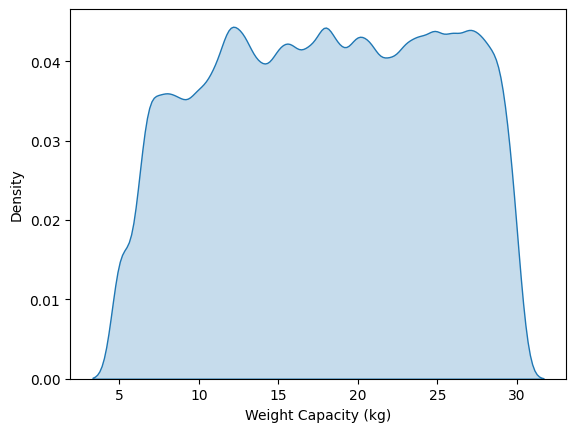

In [19]:
# KDE Plot using Seaborn
sns.kdeplot(train_df['Weight Capacity (kg)'], fill=True)  # 'fill=True' for a shaded area
plt.show()


In [20]:
train_df['Compartments'].value_counts(dropna=False)

Compartments
1     31568
4     31498
2     30595
3     30293
7     30158
9     29965
5     29959
10    29815
8     28909
6     27240
Name: count, dtype: int64

In [21]:
train_df['Compartments'].mode()

0    1
Name: Compartments, dtype: int64

In [22]:
#train_df['Compartments'].plot(kind='bar')

In [23]:
train_df.columns

Index(['Brand', 'Material', 'Size', 'Compartments', 'Laptop Compartment',
       'Waterproof', 'Style', 'Color', 'Weight Capacity (kg)', 'Price'],
      dtype='object')

In [24]:
train_df.isna().sum()

Brand                   9705
Material                8347
Size                    6595
Compartments               0
Laptop Compartment      7444
Waterproof              7050
Style                   7970
Color                   9950
Weight Capacity (kg)     138
Price                      0
dtype: int64

In [25]:
train_df.dtypes

Brand                    object
Material                 object
Size                     object
Compartments              int64
Laptop Compartment       object
Waterproof               object
Style                    object
Color                    object
Weight Capacity (kg)    float64
Price                   float64
dtype: object

In [87]:
class DataSummary:
    def __init__(self,df):
        self.cat_cols = ['Brand', 'Material', 'Size','Laptop Compartment', 'Waterproof', 'Style', 'Color']
        self.int_cols =  ['Compartments']
        self.float_cols = ['Weight Capacity (kg)']
        self.df = df.copy()
        self.mode_dict = {}
        self.mean_dict = {}

        self.scaler = None
    def imputer(self):
        for col in self.cat_cols + self.int_cols:
            self.mode_dict[col] = self.df[col].mode()[0]
        for col in self.float_cols:
            self.mean_dict[col] = float(self.df[col].mean())
        return {**self.mode_dict, **self.mean_dict}        
    
    def allowed_values(self):
        values_seen = {}
        for col in self.cat_cols + self.int_cols:
            values_seen[col] = self.df[col].dropna().unique().tolist()
        return values_seen
    def fit(self):
        self.mode_dict = self.imputer()
        self.allowed_values = self.allowed_values()
        self.scaler
        return self
    
    def transform(self, df=None):
        df = df if df is not None else self.df
        for col in self.cat_cols + self.int_cols:
            df[col] = df[col].fillna(self.mode_dict[col])
            df.loc[~df[col].isin(self.allowed_values[col]), col] = self.mode_dict[col]

        for col in self.cat_cols:
            df[col] = df[col].astype('category') 
        for col in self.float_cols:
            df[col] = df[col].fillna(self.mean_dict[col])
        return df

In [88]:
summary  = DataSummary(train_df)

In [89]:
fitted_values = summary.fit()

In [90]:
train_df_transformed = summary.transform()

In [91]:
train_df_transformed.head()

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Leather,Medium,7,Yes,No,Tote,Black,11.611723,112.15875
1,Jansport,Canvas,Small,10,Yes,Yes,Messenger,Green,27.078537,68.88056
2,Under Armour,Leather,Small,2,Yes,No,Messenger,Red,16.643760,39.17320
3,Nike,Nylon,Small,8,Yes,No,Messenger,Green,12.937220,80.60793
4,Adidas,Canvas,Medium,1,Yes,Yes,Messenger,Green,17.749338,86.02312


In [92]:
X = train_df_transformed.drop(columns = 'Price')
y = train_df_transformed['Price']

In [93]:
y.shape

(300000,)

In [94]:
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
model = xgb.XGBRegressor(
    objective="reg:squarederror",  # Standard objective for regression
    n_estimators=100,              # Number of trees
    learning_rate=0.1,             # Step size shrinkage
    max_depth=3,                   # Maximum depth of a tree
    random_state=42,
    enable_categorical = True
)


In [97]:
%%time

model.fit(X_train, y_train)

CPU times: total: 1.77 s
Wall time: 584 ms


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [98]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [99]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")

Mean Squared Error: 1514.3408
Mean Absolute Error: 33.6406


In [100]:
y_train.mean()

np.float64(81.44848108591667)

In [101]:
from sklearn.model_selection import KFold
import numpy as np

In [102]:
# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store RMSE scores for each fold
rmse_train, rmse_test = [], []
mae_train, mae_test = [], []

xgb_reg = model
# Perform manual cross-validation
for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx] 
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] 

    # Train the model
    xgb_reg.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    rmse_train.append(train_rmse)
    rmse_test.append(test_rmse)
    mae_train.append(train_mae)
    mae_test.append(test_mae)

    print(f"Fold {fold}: Train RMSE = {train_rmse:.4f}, Test RMSE = {test_rmse:.4f}")
    print(f"         Train MAE  = {train_mae:.4f}, Test MAE  = {test_mae:.4f}\n")

# Average scores across folds
print("Average Train RMSE:", np.mean(rmse_train))
print("Average Test RMSE:", np.mean(rmse_test))
print("Average Train MAE:", np.mean(mae_train))
print("Average Test MAE:", np.mean(mae_test))

Fold 1: Train RMSE = 38.9990, Test RMSE = 38.9156
         Train MAE  = 33.7592, Test MAE  = 33.6397

Fold 2: Train RMSE = 38.9672, Test RMSE = 39.0459
         Train MAE  = 33.7230, Test MAE  = 33.7917

Fold 3: Train RMSE = 38.9721, Test RMSE = 39.0188
         Train MAE  = 33.7293, Test MAE  = 33.7525

Fold 4: Train RMSE = 38.9581, Test RMSE = 39.0768
         Train MAE  = 33.6986, Test MAE  = 33.8834

Fold 5: Train RMSE = 38.9740, Test RMSE = 39.0099
         Train MAE  = 33.7313, Test MAE  = 33.7460

Average Train RMSE: 38.97407808080911
Average Test RMSE: 39.01341088995731
Average Train MAE: 33.72826078099855
Average Test MAE: 33.76265351822343


In [114]:
test_file = r'E:\KAGGLE\s05e02_bagpack prediction\data\test.csv'
test_df = pd.read_csv(test_file)
ids = test_df['id'].values
test_df = test_df.drop(columns=['id'])

In [115]:
test_df_processed = summary.transform(test_df)

In [116]:
y_pred = model.predict(test_df_processed)

array([300000, 300001, 300002, ..., 499997, 499998, 499999])

In [120]:
submission_df = pd.DataFrame({'id':ids, 'Price': y_pred})


In [124]:
sumission_file = "my_submission_20250224145600.csv"

In [125]:
submission_df.to_csv(sumission_file, index=False) 

In [126]:
competition_name = competition
submission_file = sumission_file
message = f"My first submission for {competition_name}"

In [127]:
api = KaggleApi()
api.authenticate()

In [129]:
import subprocess

In [130]:
command = f"kaggle competitions submit -c {competition_name} -f {submission_file} -m \"{message}\""
subprocess.run(command, shell=True)

CompletedProcess(args='kaggle competitions submit -c playground-series-s5e2 -f my_submission_20250224145600.csv -m "My first submission for playground-series-s5e2"', returncode=0)